# Load Data and see schema

In [4]:
!pip install -q kagglehub pandas polars duckdb matplotlib numpy xgboost scikit-learn 


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:

import requests
import os
import pandas as pd
import polars as pl
import duckdb
import time
import matplotlib.pyplot as plt
import numpy as np

import kagglehub
from kagglehub import KaggleDatasetAdapter

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

from xgboost import XGBClassifier
# Source of data set https://www.kaggle.com/datasets/aryan208/financial-transactions-dataset-for-fraud-detection
path_df = kagglehub.dataset_download(
    "aryan208/financial-transactions-dataset-for-fraud-detection"
)

print("Dataset path:", path_df)
print("Files:", os.listdir(path_df))

# Load CSV
df_path = os.path.join(path_df, "financial_fraud_detection_dataset.csv")
df = pd.read_csv(df_path)

print("Dataset 4 shape:", df.shape)
df.head()

c:\Users\kiero\AppData\Local\Programs\Python\Python39\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset path: C:\Users\kiero\.cache\kagglehub\datasets\aryan208\financial-transactions-dataset-for-fraud-detection\versions\1
Files: ['financial_fraud_detection_dataset.csv']
Dataset 4 shape: (5000000, 18)


,transaction_id,timestamp,sender_account,receiver_account,amount,transaction_type,merchant_category,location,device_used,is_fraud,fraud_type,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score,payment_channel,ip_address,device_hash
0,T100000,2023-08-22T09:22:43.516168,ACC877572,ACC388389,343.78,withdrawal,utilities,Tokyo,mobile,False,NaN,NaN,-0.21,3,0.22,card,13.101.214.112,D8536477
1,T100001,2023-08-04T01:58:02.606711,ACC895667,ACC944962,419.65,withdrawal,online,Toronto,atm,False,NaN,NaN,-0.14,7,0.96,ACH,172.52.47.194,D2622631
2,T100002,2023-05-12T11:39:33.742963,ACC733052,ACC377370,2773.86,deposit,other,London,pos,False,NaN,NaN,-1.78,20,0.89,card,185.98.35.23,D4823498
3,T100003,2023-10-10T06:04:43.195112,ACC996865,ACC344098,1666.22,deposit,online,Sydney,pos,False,NaN,NaN,-0.60,6,0.37,wire_transfer,107.136.36.87,D9961380
4,T100004,2023-09-24T08:09:02.700162,ACC584714,ACC497887,24.43,transfer,utilities,Toronto,mobile,False,NaN,NaN,0.79,13,0.27,ACH,108.161.108.255,D7637601


In [8]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

path = kagglehub.dataset_download("ealaxi/paysim1")
file_path = path + "/PS_20174392719_1491204439457_log.csv"

paysim = pd.read_csv(file_path)

print("PaySim shape:", paysim.shape)
paysim.sample(5)

100%|██████████| 178M/178M [00:07<00:00, 24.4MB/s] 

Extracting files...


PaySim shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
113869,11,PAYMENT,9605.59,C1333304038,0.00,0.00,M1741340388,0.00,0.00,0,0
4337094,308,CASH_OUT,87349.49,C220726502,0.00,0.00,C789404059,510492.42,597841.91,0,0
1034554,93,CASH_OUT,118738.26,C1915320184,31172.00,0.00,C8504253,7870.36,126608.61,0,0
1840786,163,CASH_IN,38718.14,C618138818,15900264.68,15938982.83,C919704560,538842.90,500124.76,0,0
1584107,155,PAYMENT,14697.88,C286582447,0.00,0.00,M2025483267,0.00,0.00,0,0


In [9]:
print(df['is_fraud'].value_counts())
print(df['is_fraud'].value_counts(normalize=True))
print(paysim['isFraud'].value_counts())
print(paysim['isFraud'].value_counts(normalize=True))

is_fraud
False    4820447
True      179553
Name: count, dtype: int64
is_fraud
False    0.964089
True     0.035911
Name: proportion, dtype: float64
isFraud
0    6354407
1       8213
Name: count, dtype: int64
isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64


# DATASET CLEANING

In [10]:
#Training dataset
# Remove duplicates
df = df.drop_duplicates()

# Fill missing values
df.fillna({
    'device_used': 'unknown',
    'location': 'unknown',
    'merchant_category': 'unknown'
}, inplace=True)

# Convert timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

# Ensure label is int
df['is_fraud'] = df['is_fraud'].astype(int)


df.head()

,transaction_id,timestamp,sender_account,receiver_account,amount,transaction_type,merchant_category,location,device_used,is_fraud,fraud_type,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score,payment_channel,ip_address,device_hash
0,T100000,2023-08-22 09:22:43.516168,ACC877572,ACC388389,343.78,withdrawal,utilities,Tokyo,mobile,0,NaN,NaN,-0.21,3,0.22,card,13.101.214.112,D8536477
1,T100001,2023-08-04 01:58:02.606711,ACC895667,ACC944962,419.65,withdrawal,online,Toronto,atm,0,NaN,NaN,-0.14,7,0.96,ACH,172.52.47.194,D2622631
2,T100002,2023-05-12 11:39:33.742963,ACC733052,ACC377370,2773.86,deposit,other,London,pos,0,NaN,NaN,-1.78,20,0.89,card,185.98.35.23,D4823498
3,T100003,2023-10-10 06:04:43.195112,ACC996865,ACC344098,1666.22,deposit,online,Sydney,pos,0,NaN,NaN,-0.60,6,0.37,wire_transfer,107.136.36.87,D9961380
4,T100004,2023-09-24 08:09:02.700162,ACC584714,ACC497887,24.43,transfer,utilities,Toronto,mobile,0,NaN,NaN,0.79,13,0.27,ACH,108.161.108.255,D7637601


In [11]:
# Testing dataset
# Remove duplicates
paysim = paysim.drop_duplicates()

# Convert step → timestamp
paysim['timestamp'] = pd.to_datetime("2025-01-01") + pd.to_timedelta(paysim['step'], unit='h')

# Rename columns
paysim.rename(columns={
    'type': 'transaction_type',
    'nameOrig': 'sender_account',
    'nameDest': 'receiver_account',
    'isFraud': 'is_fraud'
}, inplace=True)


In [12]:
# Balance features
paysim['balance_change_sender'] = paysim['newbalanceOrig'] - paysim['oldbalanceOrg']
paysim['balance_change_receiver'] = paysim['newbalanceDest'] - paysim['oldbalanceDest']

# Fraud indicator
paysim['is_large_transaction'] = (paysim['amount'] > 200000).astype(int)

# Time features
paysim = paysim.sort_values(['sender_account', 'timestamp'])
paysim['time_since_last_tx'] = paysim.groupby('sender_account')['timestamp'].diff().dt.total_seconds()

In [13]:
df = df.sort_values(['sender_account', 'timestamp'])

# Time feature
df['time_since_last_tx'] = df.groupby('sender_account')['timestamp'].diff().dt.total_seconds()

# Behavioral features
df['avg_amount_user'] = df.groupby('sender_account')['amount'].transform('mean')
df['amount_deviation'] = df['amount'] - df['avg_amount_user']

# Time pattern
df['hour'] = df['timestamp'].dt.hour
df['is_night'] = ((df['hour'] < 6) | (df['hour'] > 22)).astype(int)

In [14]:
df.sample(10)


,transaction_id,timestamp,sender_account,receiver_account,amount,transaction_type,merchant_category,location,device_used,is_fraud,...,velocity_score,geo_anomaly_score,payment_channel,ip_address,device_hash,time_since_last_tx,avg_amount_user,amount_deviation,hour,is_night
35490,T135490,2023-10-16 17:40:30.875008,ACC766960,ACC415447,16.59,transfer,grocery,Toronto,web,0,...,14,0.01,wire_transfer,9.48.81.62,D9657442,3.175156e+05,134.070000,-117.480000,17.0,0
11172,T111172,2023-09-07 12:22:15.737045,ACC707840,ACC216839,41.43,payment,travel,Tokyo,pos,0,...,3,0.34,card,210.186.121.145,D9058427,8.216020e+06,274.142500,-232.712500,12.0,0
2743705,T2843705,2023-09-03 08:06:39.241484,ACC871090,ACC739493,538.46,deposit,restaurant,Toronto,mobile,0,...,14,0.19,wire_transfer,50.112.202.57,D3028147,4.800723e+06,514.783750,23.676250,8.0,0
242526,T342526,2023-11-11 04:34:09.330404,ACC808553,ACC662249,46.17,payment,online,Berlin,pos,0,...,18,0.87,card,255.27.42.225,D7238508,7.055077e+06,399.897500,-353.727500,4.0,1
1121523,T1221523,2023-07-17 19:45:50.502653,ACC988766,ACC363959,322.56,withdrawal,utilities,Berlin,pos,0,...,12,0.30,wire_transfer,124.209.12.5,D9672089,1.608598e+07,500.056000,-177.496000,19.0,0
3117218,T3217218,2023-03-24 10:31:15.743023,ACC638893,ACC750533,135.27,payment,grocery,Toronto,web,0,...,11,0.62,card,73.58.165.248,D6717182,3.862779e+06,73.128000,62.142000,10.0,0
4558621,T4658621,2023-04-16 13:57:37.232315,ACC787999,ACC675143,305.28,withdrawal,utilities,London,web,1,...,10,0.79,ACH,116.189.234.81,D3526864,3.702845e+06,503.444000,-198.164000,13.0,0
1683723,T1783723,2023-11-29 03:07:19.308254,ACC856192,ACC783632,694.75,deposit,utilities,Tokyo,atm,0,...,19,0.54,card,98.243.140.80,D2067270,1.267407e+07,742.963333,-48.213333,3.0,1
3457573,T3557573,2023-06-13 14:26:42.217330,ACC335161,ACC187310,782.46,withdrawal,utilities,Toronto,web,0,...,20,0.74,ACH,23.21.25.252,D9524468,8.252077e+06,697.733333,84.726667,14.0,0
3274740,T3374740,2023-03-19 05:16:03.546588,ACC857495,ACC173838,1452.88,deposit,online,Sydney,atm,0,...,6,0.38,card,122.50.172.107,D4399209,NaN,432.975000,1019.905000,5.0,1


In [15]:
# Add missing columns to PaySim
for col in ['merchant_category', 'location', 'device_used']:
    paysim[col] = 'unknown'

# Select common columns
common_cols = [
    'timestamp',
    'transaction_type',
    'amount',
    'sender_account',
    'receiver_account',
    'is_fraud',
    'time_since_last_tx'
]

df_sub = df[common_cols].copy()
paysim_sub = paysim[common_cols].copy()

# Add source column
df_sub['source'] = 'dataset'
paysim_sub['source'] = 'paysim'

# Merge
final_df = pd.concat([df_sub, paysim_sub], ignore_index=True)

# Final clean
final_df = final_df.fillna(0)

print("Final dataset shape:", final_df.shape)
final_df.head()

Final dataset shape: (11362620, 8)


,timestamp,transaction_type,amount,sender_account,receiver_account,is_fraud,time_since_last_tx,source
0,2023-07-21 18:42:27.185407,transfer,38.26,ACC100000,ACC140110,0,0.000000e+00,dataset
1,2023-09-05 01:29:31.912064,payment,98.48,ACC100001,ACC176449,0,0.000000e+00,dataset
2,2023-12-27 21:20:18.603045,payment,280.42,ACC100001,ACC732047,0,9.834647e+06,dataset
3,2023-05-17 13:27:04.779612,transfer,26.94,ACC100002,ACC661173,0,0.000000e+00,dataset
4,2023-08-22 08:37:49.428281,transfer,60.52,ACC100002,ACC518029,0,8.363445e+06,dataset


possible other data sets
https://huggingface.co/datasets/CiferAI/Cifer-Fraud-Detection-Dataset-AF has a flagged feature the see (can be better to use to see false postives)

https://www.kaggle.com/datasets/ealaxi/paysim1

https://github.com/necst/amaretto_dataset

## Comments from teacher
Look for how it was flagged\
if data was collected by human we can compare vs  our model\
check the time difference between the different entry\
make a bin predictor for fraud\
look in to  (lightgbm xgboost SHAP)


In [18]:
print(df['timestaamp'].dtype)


KeyError: 'timestaamp'

# Model

Features

In [19]:
full_features = [
    'amount',
    'time_since_last_tx',
    'spending_deviation_score',
    'velocity_score',
    'geo_anomaly_score'
]
common_features = [
    'amount',
    'time_since_last_tx'
]

In [20]:
X_full = df[full_features]
y_full = df['is_fraud']

X_common = df[common_features]
y_common = df['is_fraud']

In [21]:
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)
X_train_common, X_test_common, y_train_common, y_test_common = train_test_split(
    X_common, y_common, test_size=0.2, random_state=42
)

Training

In [22]:
model_A = XGBClassifier()

model_A.fit(X_train_full, y_train_full)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [23]:
model_B = XGBClassifier()

model_B.fit(X_train_common, y_train_common)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [24]:
y_pred_A = model_A.predict(X_test_full)

In [25]:
y_pred_B = model_B.predict(X_test_common)

In [26]:
print("MODEL A (FULL FEATURES)")
print("Accuracy:", accuracy_score(y_test_full, y_pred_A))
print("F1 Score:", f1_score(y_test_full, y_pred_A))

print("Confusion Matrix:")
print(confusion_matrix(y_test_full, y_pred_A))

print("Classification Report:")
print(classification_report(y_test_full, y_pred_A))

MODEL A (FULL FEATURES)
Accuracy: 0.96387
F1 Score: 0.0
Confusion Matrix:
[[963870      0]
 [ 36130      0]]
Classification Report:


c:\Users\kiero\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\kiero\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\kiero\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

              precision    recall  f1-score   support

           0       0.96      1.00      0.98    963870
           1       0.00      0.00      0.00     36130

    accuracy                           0.96   1000000
   macro avg       0.48      0.50      0.49   1000000
weighted avg       0.93      0.96      0.95   1000000



In [27]:
print("\nMODEL B (COMMON FEATURES)")
print("Accuracy:", accuracy_score(y_test_common, y_pred_B))
print("F1 Score:", f1_score(y_test_common, y_pred_B))

print("Confusion Matrix:")
print(confusion_matrix(y_test_common, y_pred_B))

print("Classification Report:")
print(classification_report(y_test_common, y_pred_B))


MODEL B (COMMON FEATURES)
Accuracy: 0.96387
F1 Score: 0.0
Confusion Matrix:
[[963870      0]
 [ 36130      0]]
Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98    963870
           1       0.00      0.00      0.00     36130

    accuracy                           0.96   1000000
   macro avg       0.48      0.50      0.49   1000000
weighted avg       0.93      0.96      0.95   1000000



c:\Users\kiero\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\kiero\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\kiero\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

In [28]:

# Get feature importance from Model A
importance = model_A.feature_importances_

# Match with feature names
feature_importance_df = pd.DataFrame({
    'Feature': X_train_full.columns,
    'Importance': importance
})

# Sort
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print(feature_importance_df.head(10))

                    Feature  Importance
1        time_since_last_tx    0.216092
4         geo_anomaly_score    0.199508
2  spending_deviation_score    0.197331
0                    amount    0.193603
3            velocity_score    0.193466


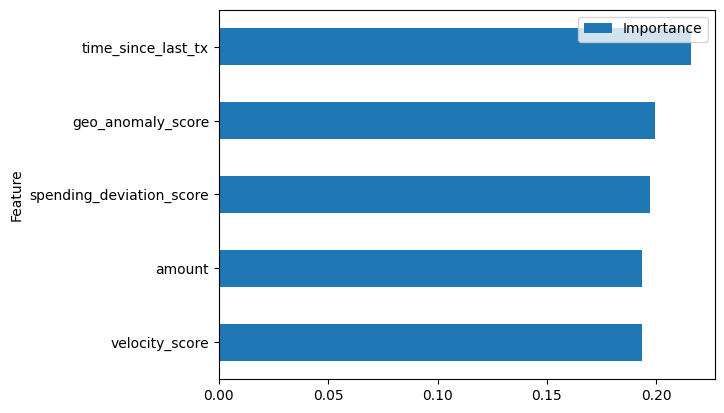

In [29]:
feature_importance_df.head(10).plot(
    x='Feature',
    y='Importance',
    kind='barh'
)
plt.gca().invert_yaxis()
plt.show()

In [30]:
!pip install lightgbm shap


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
import lightgbm as lgb
import shap

In [32]:
model_C_features = [
    'amount',
    'time_since_last_tx',
    'avg_amount_user',
    'amount_deviation',
    'hour',
    'is_night'
]

In [33]:
X_C = df[model_C_features]
y_C = df['is_fraud']

X_train_C, X_test_C, y_train_C, y_test_C = train_test_split(
    X_C, y_C, test_size=0.2, random_state=42
)

In [34]:
model_C = lgb.LGBMClassifier()

model_C.fit(X_train_C, y_train_C)
y_pred_C = model_C.predict(X_test_C)

[LightGBM] [Info] Number of positive: 143423, number of negative: 3856577
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.080850 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1046
[LightGBM] [Info] Number of data points in the train set: 4000000, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035856 -> initscore=-3.291737
[LightGBM] [Info] Start training from score -3.291737


In [35]:
print("\nMODEL C (LIGHTGBM)")
print("Accuracy:", accuracy_score(y_test_C, y_pred_C))
print("F1 Score:", f1_score(y_test_C, y_pred_C))

print("Confusion Matrix:")
print(confusion_matrix(y_test_C, y_pred_C))

print("Classification Report:")
print(classification_report(y_test_C, y_pred_C))


MODEL C (LIGHTGBM)
Accuracy: 0.96387
F1 Score: 0.0
Confusion Matrix:
[[963870      0]
 [ 36130      0]]
Classification Report:


c:\Users\kiero\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\kiero\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.96      1.00      0.98    963870
           1       0.00      0.00      0.00     36130

    accuracy                           0.96   1000000
   macro avg       0.48      0.50      0.49   1000000
weighted avg       0.93      0.96      0.95   1000000



c:\Users\kiero\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Shap values
explainer = shap.TreeExplainer(model_C)
shap_values = explainer.shap_values(X_test_C)
shap.summary_plot(shap_values, X_test_C, plot_type="bar")